# Ingestao e Avaliacao de Qualidade dos Dados

A camada bronze e o primeiro estagio. Seu objetivo e carregar os dados brutos exatamente como recebidos, aplicar tipos de dados corretos e produzir um relatorio de qualidade documentando cada anomalia encontrada. Nenhum dado e corrigido ou removido nessa etapa, os problemas sao identificados e documentados ao final do notebook.

**Fontes:** `data/raw/orders.csv`, `data/raw/production.csv`, `data/raw/inventory.csv`  
**Saidas:** arquivos Parquet em `data/bronze/` e `data/bronze/quality_report.json`

In [1]:
import json
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path('..')
RAW = ROOT / 'data' / 'raw'
BRONZE = ROOT / 'data' / 'bronze'

sns.set_theme(style='whitegrid', palette='muted')

## Carregamento dos Dados Brutos

O DuckDB le os CSVs diretamente e converte todas as colunas para os tipos corretos. Datas sao tratadas como `DATE`, campos inteiros como `INTEGER`. Esta etapa replica o que o script `src/bronze.py` faz — a diferenca aqui e que exploramos os resultados intermediarios em cada passo.

In [2]:
conn = duckdb.connect()

conn.execute(f"""
    CREATE TABLE pedidos AS
    SELECT
        CAST(order_id AS INTEGER)                 AS order_id,
        region, product,
        CAST(order_date AS DATE)                  AS order_date,
        CAST(requested_delivery_date AS DATE)     AS requested_delivery_date,
        CAST(actual_delivery_date AS DATE)        AS actual_delivery_date,
        CAST(quantity AS INTEGER)                 AS quantity
    FROM read_csv('{RAW}/orders.csv', header=true, auto_detect=true)
""")

conn.execute(f"""
    CREATE TABLE producao AS
    SELECT
        CAST(date AS DATE)                        AS date,
        plant, region, product,
        CAST(produced_quantity AS INTEGER)        AS produced_quantity,
        CAST(production_capacity AS INTEGER)      AS production_capacity
    FROM read_csv('{RAW}/production.csv', header=true, auto_detect=true)
""")

conn.execute(f"""
    CREATE TABLE estoque AS
    SELECT
        CAST(date AS DATE)                        AS date,
        region, product,
        CAST(stock_level AS INTEGER)              AS stock_level,
        CAST(warehouse_capacity AS INTEGER)       AS warehouse_capacity
    FROM read_csv('{RAW}/inventory.csv', header=true, auto_detect=true)
""")

pedidos  = conn.execute("SELECT * FROM pedidos").df()
producao = conn.execute("SELECT * FROM producao").df()
estoque  = conn.execute("SELECT * FROM estoque").df()

display(pedidos.head(3))
display(producao.head(3))
display(estoque.head(3))

contagens = pd.DataFrame({
    'tabela': ['pedidos', 'producao', 'estoque'],
    'linhas': [len(pedidos), len(producao), len(estoque)],
})
contagens

,order_id,region,product,order_date,requested_delivery_date,actual_delivery_date,quantity
0,1,LATAM,A,2023-01-01,2023-01-06,2023-01-09,1037
1,2,LATAM,C,2023-01-01,2023-01-06,2023-01-03,845
2,3,NA,A,2023-01-01,2023-01-06,2023-01-13,1956


,date,plant,region,product,produced_quantity,production_capacity
0,2023-01-01,P_LATAM,LATAM,A,1997,3989
1,2023-01-01,P_LATAM,LATAM,B,2735,2508
2,2023-01-01,P_LATAM,LATAM,C,3312,2925


,date,region,product,stock_level,warehouse_capacity
0,2023-01-01,LATAM,A,11230,12795
1,2023-01-01,LATAM,B,15274,14600
2,2023-01-01,LATAM,C,2168,11939


,tabela,linhas
0,pedidos,6282
1,producao,8772
2,estoque,8772


In [3]:
dias_distintos = estoque['date'].nunique()
produtos_unicos = estoque['product'].nunique()
regioes_unicas = estoque['region'].nunique()
combinacoes = estoque[['region', 'product']].drop_duplicates().shape[0]
esperado = 730 * regioes_unicas * produtos_unicos
observado = len(estoque)

produtos_lista = sorted(estoque['product'].dropna().unique())
regioes_lista = sorted(estoque['region'].dropna().unique())

print(f"Regioes unicas: {regioes_unicas}")
print(f"Produtos unicos: {produtos_unicos}")
print(f"Combinacoes regiao/produto: {combinacoes}")
print(f"Datas distintas: {dias_distintos}")
print(f"Registros esperados (730 dias * {regioes_unicas} regioes * {produtos_unicos} produtos): {esperado}")
print(f"Registros observados: {observado} (excesso: {observado - esperado})")
print(f"Lista de produtos: {produtos_lista}")
print(f"Lista de regioes: {regioes_lista}")

Regioes unicas: 4
Produtos unicos: 3
Combinacoes regiao/produto: 12
Datas distintas: 731
Registros esperados (730 dias * 4 regioes * 3 produtos): 8760
Registros observados: 8772 (excesso: 12)
Lista de produtos: ['A', 'B', 'C']
Lista de regioes: ['APAC', 'EU', 'LATAM', 'NA']


In [4]:
print(estoque['product'].value_counts(dropna=False))
print(estoque['region'].value_counts(dropna=False))

product
A    2924
B    2924
C    2924
Name: count, dtype: int64
region
LATAM    2193
NA       2193
EU       2193
APAC     2193
Name: count, dtype: int64


**Nota:** Neste notebook, `NA` e tratado como regiao (North America, por exemplo), nao como marcador de "Not Applicable".

## Analise de Nulos

Valores nulos em dados operacionais podem indicar registros faltantes, integracoes incompletas ou campos que por definicao nem sempre sao preenchidos. Contamos os nulos por coluna nas tres tabelas.

In [5]:
nulos_pedidos  = pedidos.isnull().sum()
nulos_producao = producao.isnull().sum()
nulos_estoque  = estoque.isnull().sum()

display(nulos_pedidos)
display(nulos_producao)
display(nulos_estoque)

order_id                     0
region                       0
product                      0
order_date                   0
requested_delivery_date      0
actual_delivery_date       306
quantity                     0
dtype: int64

date                   0
plant                  0
region                 0
product                0
produced_quantity      0
production_capacity    0
dtype: int64

date                  0
region                0
product               0
stock_level           0
warehouse_capacity    0
dtype: int64

**Interpretacao:** `actual_delivery_date` tem 306 nulos. Sao pedidos registrados mas ainda nao entregues ou registros com data de entrega ausente. Serao preservados em todas as camadas downstream com colunas derivadas nulas (`delay_days`, `on_time`). Nenhuma outra coluna possui nulos.

## Analise de Duplicatas

Cada tabela possui uma chave primaria definida. Duplicatas na chave primaria indicam problemas de integridade que devem ser documentados antes de qualquer agregacao.

In [6]:
dupes_pedidos  = pedidos.groupby('order_id').size().gt(1).sum()
dupes_producao = producao.groupby(['date', 'plant', 'product']).size().gt(1).sum()
dupes_estoque  = estoque.groupby(['date', 'region', 'product']).size().gt(1).sum()

print(f'pedidos  (order_id):              {dupes_pedidos}')
print(f'producao (date, plant, product):  {dupes_producao}')
print(f'estoque  (date, region, product): {dupes_estoque}')

pedidos  (order_id):              123
producao (date, plant, product):  0
estoque  (date, region, product): 0


**Interpretacao:**
- `pedidos`: 123 grupos de `order_id` duplicado — inesperado, pois `order_id` deveria ser a chave primaria. Esses duplicados precisam ser investigados antes dos calculos de OTIF.
- `producao` e `estoque`: 0 duplicatas nas chaves compostas. Os 12 registros extras (8.772 vs. 8.760 esperado) nao sao duplicatas — provavelmente sao datas fora do intervalo 2023-2024 ou uma combinacao adicional de regiao/produto.

## Anomalias de Estoque

In [7]:
estoque_negativo = estoque[estoque['stock_level'] <= 0]
estoque_negativo = estoque_negativo.groupby(['region', 'product']).agg(
    dias=('stock_level', 'count'),
    estoque_minimo=('stock_level', 'min')
).reset_index().sort_values('dias', ascending=False, ignore_index=True)

estoque_overflow = estoque[estoque['stock_level'] > estoque['warehouse_capacity']].copy()
estoque_overflow['excesso'] = estoque_overflow['stock_level'] - estoque_overflow['warehouse_capacity']
overflow = estoque_overflow.groupby(['region', 'product']).agg(
    dias=('excesso', 'count'),
    excesso_maximo=('excesso', 'max')
).reset_index().sort_values('dias', ascending=False, ignore_index=True)

display(estoque_negativo)
display(overflow)

,region,product,dias,estoque_minimo
0,EU,A,35,-468
1,EU,C,34,-497
2,APAC,C,32,-487
3,NA,C,32,-453
4,EU,B,30,-498
5,LATAM,C,28,-494
6,NA,B,28,-482
7,NA,A,27,-483
8,APAC,B,25,-499
9,LATAM,B,24,-487


,region,product,dias,excesso_maximo
0,LATAM,C,129,1943
1,LATAM,A,119,1978
2,NA,C,118,1960
3,APAC,B,117,1999
4,EU,C,112,1996
5,NA,B,109,1984
6,APAC,A,108,1976
7,APAC,C,105,1942
8,EU,B,104,1982
9,LATAM,B,98,1995


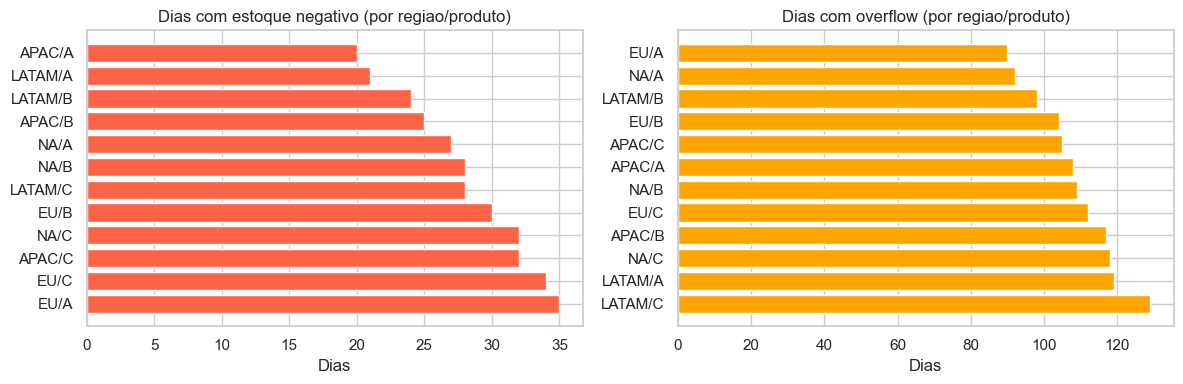

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

estoque_negativo['rotulo'] = estoque_negativo['region'] + '/' + estoque_negativo['product']
eixos[0].barh(estoque_negativo['rotulo'], estoque_negativo['dias'], color='tomato')
eixos[0].set_title('Dias com estoque negativo (por regiao/produto)')
eixos[0].set_xlabel('Dias')

overflow['rotulo'] = overflow['region'] + '/' + overflow['product']
eixos[1].barh(overflow['rotulo'], overflow['dias'], color='orange')
eixos[1].set_title('Dias com overflow (por regiao/produto)')
eixos[1].set_xlabel('Dias')

plt.tight_layout()
plt.show()

Dois tipos de anomalia existem em `inventory.csv`:

1. **Estoque negativo** (`stock_level <= 0`): Fisicamente impossivel em um armazem real. Provavelmente representa backorders (demanda comprometida sem estoque disponivel) ou um artefato do sistema de dados.
2. **Overflow** (`stock_level > warehouse_capacity`): Estoque acima da capacidade declarada do armazem, sugerindo armazenagem temporaria, sub-relato de capacidade ou erros de registro.

## Anomalias de Producao

Alguns registros de producao apresentam `produced_quantity > production_capacity`. Na pratica, isso pode significar turnos extras, sub-relato de capacidade ou erros de entrada de dados. Quantificamos a frequencia e magnitude dessas violacoes.

In [9]:
producao_acima = producao.assign(
    excesso=producao['produced_quantity'] - producao['production_capacity']
).query('excesso > 0')

acima_capacidade = (producao_acima
    .groupby(['plant', 'product'])
    .agg(dias=('excesso', 'count'), excesso_medio=('excesso', 'mean'))
    .round({'excesso_medio': 0})
    .reset_index()
    .sort_values('dias', ascending=False, ignore_index=True))
acima_capacidade

,plant,product,dias,excesso_medio
0,P_NA,B,175,251.0
1,P_LATAM,C,173,292.0
2,P_APAC,B,172,265.0
3,P_NA,C,171,284.0
4,P_APAC,C,169,290.0
5,P_EU,A,168,271.0
6,P_LATAM,B,167,266.0
7,P_NA,A,166,274.0
8,P_EU,C,164,279.0
9,P_EU,B,148,288.0


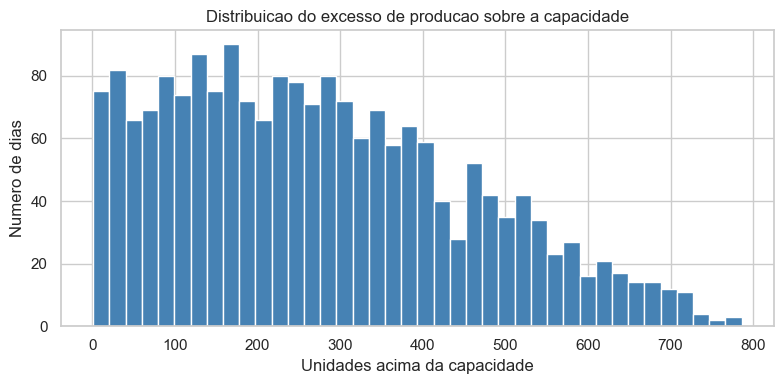

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(producao_acima['excesso'], bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribuicao do excesso de producao sobre a capacidade')
ax.set_xlabel('Unidades acima da capacidade')
ax.set_ylabel('Numero de dias')
plt.tight_layout()
plt.show()

## Detalhe das Duplicatas em Pedidos

Os 123 grupos de `order_id` duplicado merecem inspecao detalhada. Se o mesmo `order_id` mapeia para regioes ou produtos diferentes, é uma violacao de integridade de dados. Se mapeia para o mesmo registro, é uma duplicacao simples.

In [11]:
ids_duplos = pedidos[pedidos.duplicated('order_id', keep=False)]['order_id'].unique()
amostra_dupes = (pedidos[pedidos['order_id'].isin(ids_duplos)]
    .sort_values('order_id')
    .head(10)
    .reset_index(drop=True))

duplicatas = pedidos[pedidos.duplicated('order_id', keep=False)]
variacao = (duplicatas
    .groupby('order_id')
    .agg({col: pd.Series.nunique for col in pedidos.columns if col != 'order_id'}))

ids_nao_identicos = variacao[variacao.max(axis=1) > 1].index
nao_identicos = (duplicatas[duplicatas['order_id'].isin(ids_nao_identicos)]
    .sort_values('order_id')
    .reset_index(drop=True))

grupos_totalmente_identicos = (variacao.max(axis=1) == 1).sum()

print(f'Grupos de order_id duplicado: {len(ids_duplos)}')
print(f'Grupos totalmente identicos: {grupos_totalmente_identicos}')
print(f'Grupos com divergencias: {len(ids_nao_identicos)}')
print(f'Duplicatas nao identicas (registros): {len(nao_identicos)}')

display(amostra_dupes)
if len(nao_identicos) > 0:
    display(nao_identicos.head(10))
else:
    print('Nenhuma duplicata nao identica encontrada.')

Grupos de order_id duplicado: 123
Grupos totalmente identicos: 123
Grupos com divergencias: 0
Duplicatas nao identicas (registros): 0


,order_id,region,product,order_date,requested_delivery_date,actual_delivery_date,quantity
0,33,NA,B,2023-01-04,2023-01-09,2023-01-09,511
1,33,NA,B,2023-01-04,2023-01-09,2023-01-09,511
2,45,EU,C,2023-01-05,2023-01-10,NaT,1195
3,45,EU,C,2023-01-05,2023-01-10,NaT,1195
4,70,APAC,A,2023-01-08,2023-01-13,2023-01-14,1737
5,70,APAC,A,2023-01-08,2023-01-13,2023-01-14,1737
6,112,EU,B,2023-01-13,2023-01-18,2023-01-21,2158
7,112,EU,B,2023-01-13,2023-01-18,2023-01-21,2158
8,204,APAC,C,2023-01-25,2023-01-30,2023-02-09,2997
9,204,APAC,C,2023-01-25,2023-01-30,2023-02-09,2997


Nenhuma duplicata nao identica encontrada.


In [12]:
nao_identicos.head(10)

,order_id,region,product,order_date,requested_delivery_date,actual_delivery_date,quantity


## Sumario do Relatorio de Qualidade

O relatorio gerado por `src/bronze.py` consolida todos os achados acima em um unico arquivo JSON.

In [13]:
with open(BRONZE / 'quality_report.json') as f:
    relatorio = json.load(f)

relatorio

{'orders': {'total_rows': 6282,
  'nulls_per_column': {'order_id': 0,
   'region': 0,
   'product': 0,
   'order_date': 0,
   'requested_delivery_date': 0,
   'actual_delivery_date': 306,
   'quantity': 0},
  'duplicate_primary_keys': 123},
 'production': {'total_rows': 8772,
  'nulls_per_column': {'date': 0,
   'plant': 0,
   'region': 0,
   'product': 0,
   'produced_quantity': 0,
   'production_capacity': 0},
  'duplicate_primary_keys': 0,
  'over_capacity_records': 1964},
 'inventory': {'total_rows': 8772,
  'nulls_per_column': {'date': 0,
   'region': 0,
   'product': 0,
   'stock_level': 0,
   'warehouse_capacity': 0},
  'duplicate_primary_keys': 0,
  'negative_stock_records': 336,
  'overflow_records': 1301}}

## Conclusoes

| Achado | Tabela | Quantidade | Impacto no Negocio |
|---|---|---|---|
| Nulos em `actual_delivery_date` | pedidos | 306 | OTIF nao calculavel para esses pedidos |
| `order_id` duplicado | pedidos | 123 grupos | Infla contagem de pedidos e metricas de demanda se nao tratado |
| Registros extras alem dos 8.760 esperados | producao, estoque | 12 cada | Menor; requer investigacao do intervalo de datas |
| Dias com estoque negativo | estoque | 336 | Utilizacao do armazem invalida; tratar como sinal de backorder |
| Dias com overflow | estoque | 1.301 | Problema de relato de capacidade ou overflow fisico |
| Producao acima da capacidade | producao | 1.964 | Horas extras, sub-relato de capacidade ou turno nao declarado |

Todos os dados brutos sao preservados em `data/bronze/`. As anomalias sao identificadas e quantificadas, nenhuma correcao e aplicada nessa camada. A camada silver enriquecera esses registros com flags derivados e deduplicacao onde apropriado.

In [14]:
conn.close()